In [34]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
print(df.shape)
print(df['label'].value_counts())

(5572, 3)
label
0    4825
1     747
Name: count, dtype: int64


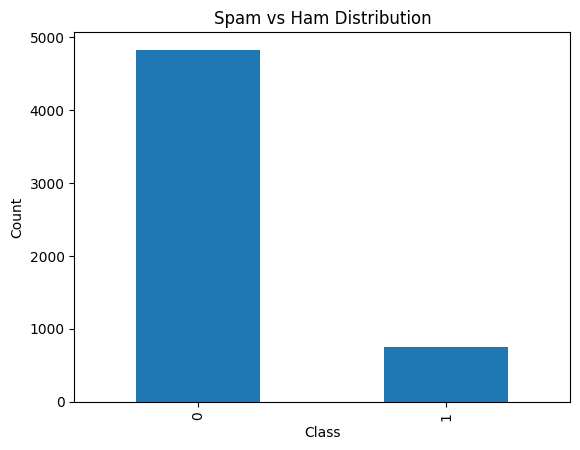

In [26]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [10]:
#Preprocessing

import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [12]:
#Encoding Labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

# ham = 0
# spam = 1

In [11]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [13]:
#BAG OF WORDS

from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

#Train
from sklearn.linear_model import LogisticRegression

model_bow = LogisticRegression(max_iter=1000)

model_bow.fit(X_train_bow, y_train)

#Evaluate
from sklearn.metrics import accuracy_score

pred_bow = model_bow.predict(X_test_bow)

acc_bow = accuracy_score(y_test, pred_bow)

print("BoW Accuracy:", acc_bow)

BoW Accuracy: 0.9757847533632287


In [14]:
#TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#Train
model_tfidf = LogisticRegression(max_iter=1000)

model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, pred_tfidf)

print("TF-IDF Accuracy:", acc_tfidf)

TF-IDF Accuracy: 0.95695067264574


In [15]:
#ONE-HOT ENCODING

onehot = CountVectorizer(
    binary=True,
    max_features=5000
)

X_train_onehot = onehot.fit_transform(X_train)
X_test_onehot = onehot.transform(X_test)

#Train
model_onehot = LogisticRegression(max_iter=1000)

model_onehot.fit(X_train_onehot, y_train)

pred_onehot = model_onehot.predict(X_test_onehot)

acc_onehot = accuracy_score(y_test, pred_onehot)

print("One-Hot Accuracy:", acc_onehot)

One-Hot Accuracy: 0.97847533632287


In [33]:
#Word2Vec CBOW

from gensim.models import Word2Vec

sentences = [msg.split() for msg in X_train]

cbow_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=0
)

#Vector Func
import numpy as np

def sentence_vector(sentence, model):

    words = sentence.split()

    vectors = [
        model.wv[word]
        for word in words
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

#Creating Features
X_train_cbow = np.array([
    sentence_vector(text, cbow_model)
    for text in X_train
])

X_test_cbow = np.array([
    sentence_vector(text, cbow_model)
    for text in X_test
])

#Train
model_cbow = LogisticRegression(max_iter=1000)

model_cbow.fit(X_train_cbow, y_train)

pred_cbow = model_cbow.predict(X_test_cbow)

acc_cbow = accuracy_score(y_test, pred_cbow)

print("CBOW Accuracy:", acc_cbow)

CBOW Accuracy: 0.8654708520179372


In [17]:
#SKIP-GRAM

skipgram_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1
)

#Feature
X_train_skip = np.array([
    sentence_vector(text, skipgram_model)
    for text in X_train
])

X_test_skip = np.array([
    sentence_vector(text, skipgram_model)
    for text in X_test
])

#Train
model_skip = LogisticRegression(max_iter=1000)

model_skip.fit(X_train_skip, y_train)

pred_skip = model_skip.predict(X_test_skip)

acc_skip = accuracy_score(y_test, pred_skip)

print("SkipGram Accuracy:", acc_skip)

SkipGram Accuracy: 0.9524663677130045


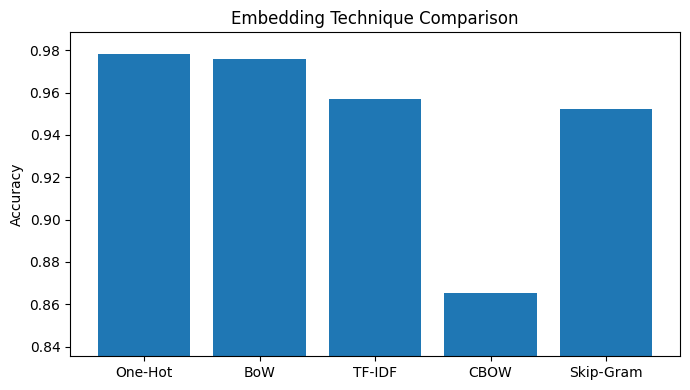

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "One-Hot": acc_onehot,
    "BoW": acc_bow,
    "TF-IDF": acc_tfidf,
    "CBOW": acc_cbow,
    "Skip-Gram": acc_skip
}

# Create DataFrame
results_df = pd.DataFrame(
    results.items(),
    columns=["Technique", "Accuracy"]
)


# Plot
plt.figure(figsize=(7,4))

bars = plt.bar(
    results_df["Technique"],
    results_df["Accuracy"]
)

# Zoom into the accuracy range
plt.ylim(
    results_df["Accuracy"].min() - 0.03,
    results_df["Accuracy"].max() + 0.01
)

plt.title("Embedding Technique Comparison")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [23]:
comparison = pd.DataFrame({
    "Embedding Technique": [
        "One-Hot",
        "Bag of Words",
        "TF-IDF",
        "CBOW",
        "Skip-Gram"
    ],
    "Accuracy (%)": [
        round(acc_onehot*100,2),
        round(acc_bow*100,2),
        round(acc_tfidf*100,2),
        round(acc_cbow*100,2),
        round(acc_skip*100,2)
    ]
})

comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)

,Embedding Technique,Accuracy (%)
0,One-Hot,97.85
1,Bag of Words,97.58
2,TF-IDF,95.70
4,Skip-Gram,95.25
3,CBOW,86.55
